# Up, down, and control geo lift with PyMC

This example estimates the revenue effect of increasing one channel in some geos and decreasing it in others. A common set of unchanged geos supplies the business-as-usual counterfactual. The simulator exposes the planted effects so we can check recovery before using the estimates as MMM calibration observations.

The analysis assumes that the control geos are unaffected by the intervention, that their pre-period relationship to treated geos remains useful after assignment, and that no other arm-specific change occurs at the intervention date. Assignment labels describe intent; the realized spend path determines the delivered intervention.

## Simulate assignment and delivered spend

The simulated USD-per-week panel has two media channels, `search` and `display`. Only `search` changes after the intervention. Up and down geos have different saturation parameters, so their known revenue effects vary by geo. Planned changes offset in total in this example, while realized changes are smaller because delivery is 90% of plan.

In [1]:
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import StrMethodFormatter

import causalpy as cp
from causalpy.data.simulate_data import generate_up_down_geolift_data

FIG_WIDTH = 8
FIG_HEIGHT = 4.5
COLOR_UP = "#237A65"
COLOR_DOWN = "#B55A45"

simulated = generate_up_down_geolift_data(seed=415, n_pre=32, n_post=8, n_control=5)
simulated.arms

{'up': ['up_1', 'up_2'],
 'down': ['down_1', 'down_2'],
 'control': ['control_1', 'control_2', 'control_3', 'control_4', 'control_5']}

The `arms` mapping is assignment. The `spend_planned` and `spend_realized` panels show what was intended and delivered, and `spend_baseline` is the business-as-usual path. The `effects` panel is known only because this example is simulated.

## Fit the counterfactual

For each treated geo and post-intervention week, the estimand is observed revenue minus the revenue that geo would have generated under its business-as-usual spend path. `UpDownGeoLift` fits one Bayesian synthetic-control model to all treated geos and retains their aligned `chain` and `draw` coordinates. The down geos are never used as unchanged donors.

In [2]:
model = cp.pymc_models.SoftmaxWeightedSumFitter(
    sample_kwargs={
        "draws": 500,
        "tune": 500,
        "chains": 2,
        "cores": 1,
        "target_accept": 0.95,
        "random_seed": 415,
        "progressbar": False,
    }
)
result = cp.UpDownGeoLift(
    simulated.revenue,
    treatment_time=simulated.treatment_time,
    arms=simulated.arms,
    model=model,
).fit()

In [3]:
result.arm_effect_table()

,level,geo,arm,mean,sd,lower_94,upper_94,window_start,window_end,n_periods,aggregate
0,geo,up_1,up,7.941863,0.116785,7.744437,8.180999,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean
1,geo,up_2,up,5.219866,0.128969,4.999669,5.492156,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean
2,geo,down_1,down,-6.582396,0.117070,-6.772135,-6.326163,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean
3,geo,down_2,down,-7.662481,0.163907,-7.935871,-7.328037,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean
4,arm,NaN,up,6.580865,0.087179,6.432323,6.758744,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean
5,arm,NaN,down,-7.122438,0.100121,-7.298190,-6.925361,2024-08-18 00:00:00,2024-10-06 00:00:00,8,mean


The table reports a signed mean effect per week for each treated geo and a separate mean for each arm. The 94% intervals summarize posterior draws after averaging within each draw, so geos in the same arm retain their joint posterior dependence. A cumulative effect is available with `aggregate='sum'`. The constructor warns that a few pre-period treated observations lie outside the donor convex hull; this is a diagnostic to examine before interpreting the narrow intervals as fully calibrated uncertainty.

## Reality check against the planted effects

The simulator records the no-intervention potential outcome and the realized intervention effect. The plot compares the planted mean weekly effect with each geo's posterior estimate over the same eight-week window.

**Caption:** Posterior mean weekly revenue effect and 94% equal-tailed interval by treated geo; open circles mark the planted mean weekly effect. Colors identify assignment arms.

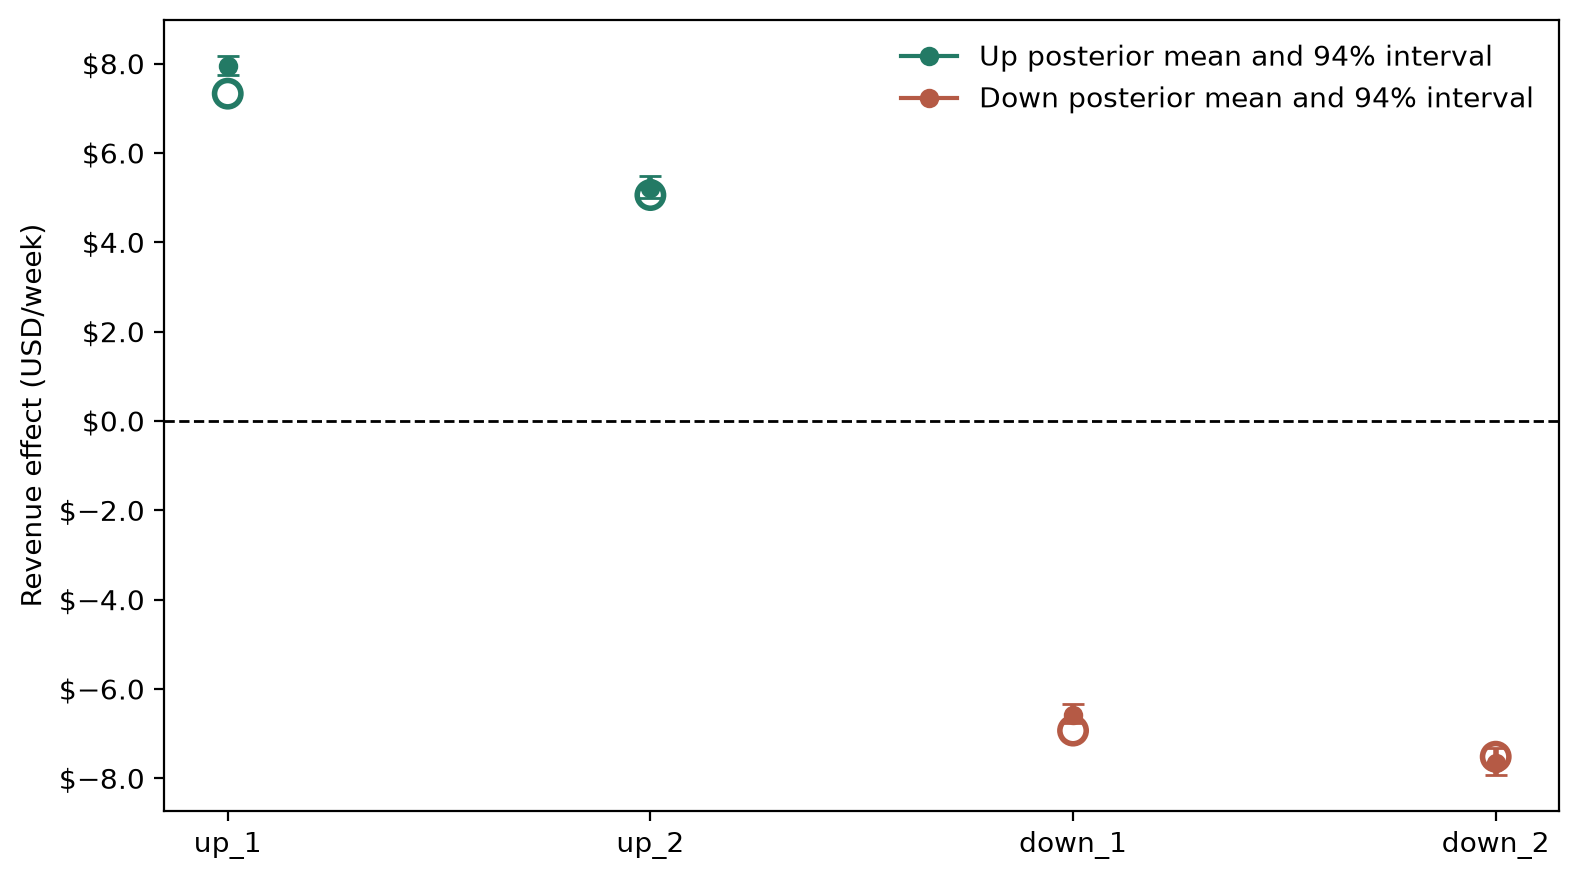

In [4]:
table = result.arm_effect_table()
geo_table = table.loc[table["level"] == "geo"].set_index("geo")
truth = simulated.effects.loc[simulated.treatment_time :].mean()
fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
for position, geo in enumerate(result.treated_units):
    row = geo_table.loc[geo]
    color = COLOR_UP if row["arm"] == "up" else COLOR_DOWN
    ax.errorbar(
        position,
        row["mean"],
        yerr=[[row["mean"] - row["lower_94"]], [row["upper_94"] - row["mean"]]],
        fmt="o",
        color=color,
        capsize=4,
        linewidth=2,
        zorder=3,
    )
    ax.scatter(
        position,
        truth[geo],
        facecolors="none",
        edgecolors=color,
        s=90,
        linewidths=2,
        zorder=4,
    )
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_xticks(range(len(result.treated_units)), result.treated_units)
ax.set_ylabel("Revenue effect (USD/week)")
ax.yaxis.set_major_formatter(StrMethodFormatter("${x:,.1f}"))
ax.legend(
    handles=[
        Line2D(
            [0],
            [0],
            color=COLOR_UP,
            marker="o",
            label="Up posterior mean and 94% interval",
        ),
        Line2D(
            [0],
            [0],
            color=COLOR_DOWN,
            marker="o",
            label="Down posterior mean and 94% interval",
        ),
    ],
    frameon=False,
    loc="best",
)
fig.tight_layout()
plt.show()

The estimated effects have the correct signs, but the planted value falls outside some 94% intervals. That is a useful warning: the fitted donor model's posterior interval does not include every source of counterfactual error in this simulated panel. Inspect pre-period fit and posterior diagnostics before using a row for calibration.

## Build scalar MMM calibration rows

For the selected complete weekly window, `x` is mean business-as-usual search spend per week, `delta_x` is mean realized minus business-as-usual search spend per week, and `delta_y` is mean signed revenue effect per week. `sigma` is the posterior standard deviation of that mean effect. The revenue and both spend panels carry `attrs["unit"] = "USD/week"`, which the exporter checks against the declared units. Both spend panels must contain every selected outcome week. Baseline spend and delivered change must remain stable across the window; otherwise a nonlinear saturation response at mean spend is not the mean response to a changing spend path. The exported rows retain arm, window, period count, and unit metadata; PyMC-Marketing uses the scalar likelihood columns plus `geo` when geo is an MMM dimension.

In [5]:
lift_rows = result.to_mmm_lift(
    spend_baseline=simulated.spend_baseline,
    spend_realized=simulated.spend_realized,
    channel=simulated.tested_channel,
    spend_unit="USD/week",
    outcome_unit="USD/week",
    start=simulated.treatment_time,
    end=simulated.revenue.index[-1],
)
lift_rows[["channel", "geo", "arm", "x", "delta_x", "delta_y", "sigma", "n_periods"]]

,channel,geo,arm,x,delta_x,delta_y,sigma,n_periods
0,search,up_1,up,32.485767,7.2,7.941863,0.116785,8
1,search,up_2,up,44.973953,7.2,5.219866,0.128969,8
2,search,down_1,down,45.138887,-7.2,-6.582396,0.117070,8
3,search,down_2,down,40.060672,-7.2,-7.662481,0.163907,8


The rows are marginal summaries for a scalar lift likelihood. The joint posterior remains available as `result.impact_draws` or through `result.aggregate_draws()`. A downstream model that needs cross-geo covariance should use those draws instead of treating the rows as independent. The simple simulator has no carryover; if an experiment has delayed effects, verify that the chosen stable response window and spend definition match the MMM's adstock convention before exporting.

## Summary

- Keep up and down effects signed and summarize the two arms separately.
- Compare model estimates with planted effects in simulated data.
- Align business-as-usual spend, delivered spend, and revenue to the same outcome periods before producing MMM rows.
- Retain joint draws when cross-geo uncertainty matters.